# M5 Final Forecasting — LightGBM Recursive 28-Day Prediction

**Configured for your exact Step 1 setup:**
- 18 features: item_id, dept_id, cat_id, store_id, state_id, is_active, sell_price, price_change, is_promo, dow, month, lag_7, lag_28, rmean_7, rmean_28, lag_56, snap_flag, is_event
- Best iteration: 152 (from Optuna trial 37)
- Validation RMSE: 2.0026

**This notebook:**
1. Loads your tuned hyperparameters from `best_lgbm_params.json`
2. Trains on **all 30,490 IDs** using the full historical data
3. Recursively forecasts 28 days ahead (F1–F28), updating **lag_7, lag_28, lag_56, rmean_7, rmean_28** at each step
4. Ensures future rows have **dow, month, snap_flag, is_event, is_active, sell_price, price_change, is_promo**
5. Maintains categorical encoding for **item_id, dept_id, cat_id, store_id, state_id**
6. Clips negative predictions to 0
7. Generates submission file: `id, F1, F2, ..., F28`

## 0. Environment Setup

In [2]:
# Uncomment if running on Colab:
!pip install lightgbm pyarrow scikit-learn -q

import os, json, warnings
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import lightgbm as lgb
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)

# Mount Google Drive if on Colab
# from google.colab import drive
# # drive.mount('/content/drive')  # Colab only  # Colab only


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Configuration

In [3]:
# Update DATA_PATH to match your local environment.
# DATA_PATH should contain:
#   - long_df_with_features.parquet  (output of notebook 03)
#   - best_lgbm_params.json          (output of notebook 04c, also in results/)
#   - calendar.csv, sell_prices.csv  (Kaggle raw data)
DATA_PATH = Path("../results")
RAW_DATA_PATH = Path("../data/raw")  # for calendar.csv and sell_prices.csv
PARAMS_PATH = DATA_PATH / "best_lgbm_params.json"  # also committed at results/best_lgbm_params.json
SUBMISSION_PATH = DATA_PATH / "m5_submission.csv"


In [4]:
FORECAST_HORIZON = 28
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# EXACT features from your Step 1 (in order)
EXPECTED_FEATURES = [
    'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id',  # Categorical (5)
    'is_active', 'sell_price', 'price_change', 'is_promo',    # Static (4)
    'dow', 'month',                                            # Calendar (2)
    'lag_7', 'lag_28', 'rmean_7', 'rmean_28', 'lag_56',       # Lag/Rolling (5)
    'snap_flag', 'is_event'                              # More static (2
]

CATEGORICAL_FEATURES = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
LAG_FEATURES = ['lag_7', 'lag_28', 'lag_56', 'rmean_7', 'rmean_28']
STATIC_FEATURES = ['is_active', 'sell_price', 'price_change', 'is_promo', 'dow', 'month', 'year', 'snap_flag', 'is_event']

print(f"Total features: {len(EXPECTED_FEATURES)}")
print(f"Categorical: {len(CATEGORICAL_FEATURES)}")
print(f"Lag/Rolling: {len(LAG_FEATURES)}")
print(f"Static: {len(STATIC_FEATURES)}")

Total features: 18
Categorical: 5
Lag/Rolling: 5
Static: 9


## 2. Load Best Hyperparameters

In [5]:
if not PARAMS_PATH.exists():
    raise FileNotFoundError(f"Cannot find {PARAMS_PATH}. Run Step 1 tuning first.")

with open(PARAMS_PATH, 'r') as f:
    best_params = json.load(f)

print("Loaded best hyperparameters from tuning:")
print(json.dumps(best_params, indent=2))

# Extract metadata
best_iteration = best_params.pop('best_iteration_from_tuning', 152)
validation_rmse = best_params.pop('validation_rmse_from_tuning', None)
source = best_params.pop('source', 'unknown')

print(f"\nSource: {source}")
print(f"Best iteration: {best_iteration}")
if validation_rmse:
    print(f"Validation RMSE: {validation_rmse:.6f}")

Loaded best hyperparameters from tuning:
{
  "objective": "tweedie",
  "metric": "rmse",
  "boosting_type": "gbdt",
  "bagging_freq": 1,
  "verbosity": -1,
  "seed": 42,
  "learning_rate": 0.041858462747989315,
  "num_leaves": 91,
  "min_data_in_leaf": 85,
  "tweedie_variance_power": 1.2765900380701871,
  "lambda_l1": 0.8683198414627746,
  "lambda_l2": 0.35976328628132526,
  "feature_fraction": 0.6987745525049156,
  "bagging_fraction": 0.8688864780847736,
  "best_iteration_from_tuning": 152,
  "validation_rmse_from_tuning": 2.002561220831971,
  "source": "optuna_trial_37"
}

Source: optuna_trial_37
Best iteration: 152
Validation RMSE: 2.002561


## 3. Load Full Dataset

In [6]:
df = pd.read_parquet(DATA_PATH / "long_df_with_features.parquet")  # output of notebook 03

print(f"   Shape: {df.shape}")
print(f"   Unique IDs: {df['id'].nunique():,}")
print(f"   Columns: {df.columns.tolist()}")

display(df.head())


   Shape: (16098720, 21)
   Unique IDs: 30,490
   Columns: ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'date', 'demand', 'is_active', 'sell_price', 'price_change', 'is_promo', 'dow', 'month', 'lag_7', 'lag_28', 'rmean_7', 'rmean_28', 'lag_56', 'snap_flag', 'is_event']


,id,item_id,dept_id,cat_id,store_id,state_id,date,demand,is_active,sell_price,price_change,is_promo,dow,month,lag_7,lag_28,rmean_7,rmean_28,lag_56,snap_flag,is_event
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2014-12-12,1,1,2.24,0.0,0,4,12,NaN,NaN,NaN,NaN,NaN,0,0
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2014-12-13,2,1,2.24,0.0,0,5,12,NaN,NaN,NaN,NaN,NaN,0,0
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2014-12-14,2,1,2.24,0.0,0,6,12,NaN,NaN,NaN,NaN,NaN,0,0
3,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2014-12-15,1,1,2.24,0.0,0,0,12,NaN,NaN,NaN,NaN,NaN,0,0
4,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2014-12-16,1,1,2.24,0.0,0,1,12,NaN,NaN,NaN,NaN,NaN,0,0


## 4. Identify Key Columns and Create day_num

In [7]:
# Identify key columns
TARGET = 'sales' if 'sales' in df.columns else 'demand'
ID_COL = 'id'
TIME_COL = 'd' if 'd' in df.columns else 'date'

print(f"TARGET: {TARGET}")
print(f"ID_COL: {ID_COL}")
print(f"TIME_COL: {TIME_COL}")

# --- THE FIX: Map absolute day numbers from the calendar ---
# Load calendar to get the true absolute Kaggle day numbers (d_1 to d_1969)
calendar = pd.read_csv(RAW_DATA_PATH / "calendar.csv")
calendar["date"] = pd.to_datetime(calendar["date"])
calendar["abs_day_num"] = calendar["d"].str.replace('d_', '', regex=False).astype(int)

# Merge the true day numbers into your historical dataframe
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors='coerce')
df = df.merge(calendar[["date", "abs_day_num"]], left_on=TIME_COL, right_on="date", how="left")

# Assign the true day numbers and clean up
df["day_num"] = df["abs_day_num"]
df.drop(columns=["abs_day_num"], inplace=True)

# Add year feature (captures year-over-year demand trends)
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df["year"] = df[TIME_COL].dt.year
if TIME_COL != "date":
    df.drop(columns=["date"], errors="ignore", inplace=True)

max_train_day = int(df['day_num'].max())
print(f"\nMax training day: {max_train_day}")
print(f"Will forecast days {max_train_day + 1} to {max_train_day + FORECAST_HORIZON}")


TARGET: demand
ID_COL: id
TIME_COL: date

Max training day: 1941
Will forecast days 1942 to 1969


## 5. Verify Features Match Step 1

In [8]:
# Check if all expected features exist
missing_features = [f for f in EXPECTED_FEATURES if f not in df.columns]

if missing_features:
    print(f"⚠️  WARNING: Missing features from Step 1: {missing_features}")
    print(f"   Available columns: {df.columns.tolist()}")
    raise ValueError("Feature mismatch! Check your data.")

print(" All 18 expected features found in data")

# Ensure categorical columns are properly typed
for col in CATEGORICAL_FEATURES:
    df[col] = df[col].astype('category')

 All 18 expected features found in data


## 6. Prepare Training Data

In [9]:
# Drop rows with NaN lag features
before = len(df)
train_df = df.dropna(subset=LAG_FEATURES).copy()
print(f"Dropped {before - len(train_df):,} rows with NaN lag features ({(before - len(train_df)) / before:.1%})")

# Prepare training matrices
X_train = train_df[EXPECTED_FEATURES]
y_train = train_df[TARGET]

print(f"   X_train shape: {X_train.shape}")
print(f"   y_train shape: {y_train.shape}")
print(f"\n   Target stats:")
print(f"   Mean: {y_train.mean():.2f}")
print(f"   Median: {y_train.median():.2f}")
print(f"   Max: {y_train.max():.0f}")
print(f"   Zero sales: {(y_train == 0).sum():,} ({(y_train == 0).sum() / len(y_train):.1%})")

Dropped 1,707,440 rows with NaN lag features (10.6%)
   X_train shape: (14391280, 18)
   y_train shape: (14391280,)

   Target stats:
   Mean: 1.29
   Median: 0.00
   Max: 349
   Zero sales: 8,598,198 (59.7%)


## 7. Train Final Model on All Data

In [10]:
# lgb_train = lgb.Dataset(
#     X_train,
#     label=y_train,
#     categorical_feature=CATEGORICAL_FEATURES,
#     free_raw_data=False
# )

# # CHANGED: use FINAL_BOOST_ROUND instead of best_iteration from tuning
# # best_iteration (152) was tuned on 1000-ID subset — likely underfits the full 30K dataset
# # 500 gives the model enough capacity to learn from the much larger training set
# #FINAL_BOOST_ROUND = 500

# model = lgb.train(
#     params=best_params,
#     train_set=lgb_train,
#     num_boost_round=best_iteration,   # 152
#     callbacks=[lgb.log_evaluation(50)]
# )
# 改成 ensemble — 三個 seed，其他 params 不變
seeds = [42, 123, 2024]
models = []

for seed in seeds:
    params_s = {**best_params, 'seed': seed}

    lgb_ds = lgb.Dataset(
        X_train,
        label=y_train,
        categorical_feature=CATEGORICAL_FEATURES,
        free_raw_data=False
    )
    m = lgb.train(
        params=params_s,
        train_set=lgb_ds,
        num_boost_round=best_iteration,  # 152
        callbacks=[lgb.log_evaluation(50)]
    )
    models.append(m)
    print(f'✅ Seed {seed} done')

print(f'\nTotal models trained: {len(models)}')

✅ Seed 42 done
✅ Seed 123 done
✅ Seed 2024 done

Total models trained: 3


In [11]:
# average importance across ensemble
importance = sum(
    m.feature_importance(importance_type="gain") for m in models
) / len(models)

features = models[0].feature_name()

fi_df = pd.DataFrame({
    "feature": features,
    "importance": importance
}).sort_values(by="importance", ascending=False)

print(fi_df.head(10))

       feature    importance
13     rmean_7  1.985658e+08
14    rmean_28  6.977066e+07
0      item_id  1.217732e+07
11       lag_7  9.100548e+06
12      lag_28  5.490252e+06
9          dow  2.216929e+06
15      lag_56  1.798944e+06
1      dept_id  1.558688e+06
6   sell_price  1.319846e+06
3     store_id  7.955894e+05


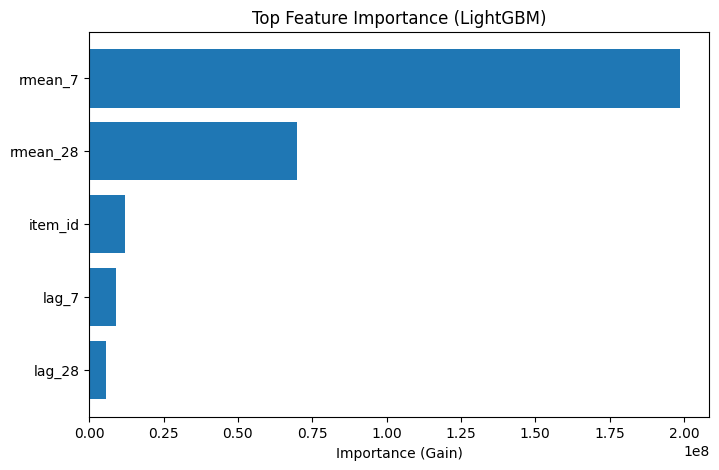

In [14]:
import matplotlib.pyplot as plt

top_n = 5

plt.figure(figsize=(8,5))
plt.barh(fi_df["feature"].head(top_n)[::-1],
         fi_df["importance"].head(top_n)[::-1])
plt.title("Top Feature Importance (LightGBM)")
plt.xlabel("Importance (Gain)")
plt.show()

## 8. Prepare Static Features for Future Days

- **dow, month** (calendar features)
- **snap_flag, is_event** (calendar events)
- **sell_price, price_change, is_promo** (pricing)
- **is_active** (product status)
- **item_id, dept_id, cat_id, store_id, state_id** (IDs)

In [ ]:
prices = pd.read_csv(RAW_DATA_PATH / "sell_prices.csv")


In [ ]:
# future calendar rows for final M5 forecast: d_1942 to d_1969
future_calendar = calendar[
    calendar["d"].isin([f"d_{i}" for i in range(1942, 1970)])
].copy()

future_calendar["day_num"] = (
    future_calendar["d"]
    .str.replace("d_", "", regex=False)
    .astype(int)
)

# base item-store info from historical df
base_ids = df[[
    "id", "item_id", "dept_id", "cat_id", "store_id", "state_id"
]].drop_duplicates().copy()

# cross join ids x future dates
base_ids["key"] = 1
future_calendar["key"] = 1

future_static_df = base_ids.merge(future_calendar, on="key").drop(columns="key")

# merge future prices
future_static_df = future_static_df.merge(
    prices,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left"
)

# target placeholder
future_static_df["demand"] = np.nan

print("Future rows:", future_static_df.shape)
print("Future day range:", future_static_df["d"].min(), "to", future_static_df["d"].max())
print("Expected rows:", base_ids["id"].nunique() * 28)

Future rows: (853720, 24)
Future day range: d_1942 to d_1969
Expected rows: 853720


In [ ]:
future_static_df["dow"] = future_static_df["date"].dt.dayofweek
future_static_df["month"] = future_static_df["date"].dt.month

future_static_df["snap_flag"] = np.where(
    future_static_df["state_id"] == "CA", future_static_df["snap_CA"],
    np.where(
        future_static_df["state_id"] == "TX", future_static_df["snap_TX"],
        future_static_df["snap_WI"]
    )
)

future_static_df["is_event"] = (
    future_static_df["event_name_1"].notna() |
    future_static_df["event_name_2"].notna()
).astype(int)

# Add year feature to match training features
future_static_df["year"] = future_static_df["date"].dt.year

In [ ]:
# Make sure sorted
future_static_df = future_static_df.sort_values(["id", "day_num"]).copy()
df = df.sort_values(["id", "day_num"]).copy()

# -----------------------------
# 1. is_active
# -----------------------------
# Future rows are active if price exists
future_static_df["is_active"] = future_static_df["sell_price"].notna().astype(int)

# -----------------------------
# 2. price_change
# -----------------------------
# Need previous historical price + future price
price_history = pd.concat([
    df[["id", "day_num", "sell_price"]],
    future_static_df[["id", "day_num", "sell_price"]]
], ignore_index=True).sort_values(["id", "day_num"])

price_history["price_change"] = (
    price_history.groupby("id")["sell_price"].pct_change()
)

future_static_df = future_static_df.drop(
    columns=[c for c in ["price_change"] if c in future_static_df.columns],
    errors="ignore"
)

future_static_df = future_static_df.merge(
    price_history[["id", "day_num", "price_change"]],
    on=["id", "day_num"],
    how="left"
)

future_static_df["price_change"] = (
    future_static_df["price_change"]
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)

# -----------------------------
# 3. is_promo
# -----------------------------
# Define promo as price drop from previous available price
future_static_df["is_promo"] = (future_static_df["price_change"] < 0).astype(int)

In [ ]:
if len(future_static_df) == 0:
    raise ValueError("Future row creation failed. future_static_df is empty.")

print(f"✅ Found {len(future_static_df):,} future rows in data")
print(f"   Days: {int(future_static_df['day_num'].min())} to {int(future_static_df['day_num'].max())}")
print(f"   Unique IDs: {future_static_df[ID_COL].nunique():,}")

# Verify static features are present
missing_static = [f for f in STATIC_FEATURES if f not in future_static_df.columns or future_static_df[f].isnull().all()]
if missing_static:
    raise ValueError(f"Missing static features in future rows: {missing_static}")

# Ensure categorical encoding matches training
for col in CATEGORICAL_FEATURES:
    future_static_df[col] = future_static_df[col].astype('category')

print(f"\n✅ Static features verified for future days:")
print(f"   {STATIC_FEATURES}")

# Display sample
print("\nSample future static features:")
display(future_static_df[[ID_COL, 'day_num'] + STATIC_FEATURES].head(10))

✅ Found 853,720 future rows in data
   Days: 1942 to 1969
   Unique IDs: 30,490

✅ Static features verified for future days:
   ['is_active', 'sell_price', 'price_change', 'is_promo', 'dow', 'month', 'year', 'snap_flag', 'is_event']

Sample future static features:


,id,day_num,is_active,sell_price,price_change,is_promo,dow,month,year,snap_flag,is_event
0,FOODS_1_001_CA_1_evaluation,1942,1,2.24,-4.257474e-09,1,0,5,2016,0,0
1,FOODS_1_001_CA_1_evaluation,1943,1,2.24,0.000000e+00,0,1,5,2016,0,0
2,FOODS_1_001_CA_1_evaluation,1944,1,2.24,0.000000e+00,0,2,5,2016,0,0
3,FOODS_1_001_CA_1_evaluation,1945,1,2.24,0.000000e+00,0,3,5,2016,0,0
4,FOODS_1_001_CA_1_evaluation,1946,1,2.24,0.000000e+00,0,4,5,2016,0,0
5,FOODS_1_001_CA_1_evaluation,1947,1,2.24,0.000000e+00,0,5,5,2016,0,0
6,FOODS_1_001_CA_1_evaluation,1948,1,2.24,0.000000e+00,0,6,5,2016,0,0
7,FOODS_1_001_CA_1_evaluation,1949,1,2.24,0.000000e+00,0,0,5,2016,0,1
8,FOODS_1_001_CA_1_evaluation,1950,1,2.24,0.000000e+00,0,1,5,2016,0,0
9,FOODS_1_001_CA_1_evaluation,1951,1,2.24,0.000000e+00,0,2,6,2016,1,0


## 9. Helper Function for Recursive Forecasting

**Critical:** At each forecast step, we recompute:
- **lag_7:** sales from 7 days ago
- **lag_28:** sales from 28 days ago
- **lag_56:** sales from 56 days ago
- **rmean_7:** rolling mean of last 7 days
- **rmean_28:** rolling mean of last 28 days

In [ ]:
def prepare_forecast_day(current_day, history_df, static_df, id_col, target_col):
    day_features = static_df[static_df["day_num"] == current_day].copy()

    if len(day_features) == 0:
        raise ValueError(f"No static features found for day {current_day}")

    # lag features
    for lag in [7, 28, 56]:
        lag_data = history_df.loc[
            history_df["day_num"] == current_day - lag,
            [id_col, target_col]
        ].rename(columns={target_col: f"lag_{lag}"})

        day_features = day_features.merge(lag_data, on=id_col, how="left")

    # rmean_7 = mean of lag_7 over 7 days
    # equivalent to demand.shift(7).rolling(7).mean()
    r7_source = history_df[
        (history_df["day_num"] >= current_day - 13) &
        (history_df["day_num"] <= current_day - 7)
    ][[id_col, target_col]]

    rmean_7 = (
        r7_source.groupby(id_col)[target_col]
        .mean()
        .reset_index()
        .rename(columns={target_col: "rmean_7"})
    )

    day_features = day_features.merge(rmean_7, on=id_col, how="left")

    # rmean_28 = mean of lag_28 over 28 days
    # equivalent to demand.shift(28).rolling(28).mean()
    r28_source = history_df[
        (history_df["day_num"] >= current_day - 55) &
        (history_df["day_num"] <= current_day - 28)
    ][[id_col, target_col]]

    rmean_28 = (
        r28_source.groupby(id_col)[target_col]
        .mean()
        .reset_index()
        .rename(columns={target_col: "rmean_28"})
    )

    day_features = day_features.merge(rmean_28, on=id_col, how="left")

    for col in ["lag_7", "lag_28", "lag_56", "rmean_7", "rmean_28"]:
        day_features[col] = day_features[col].fillna(0)

    return day_features

## 10. Recursive 28-Day Forecasting Loop

For each of 28 days:
1. Compute lag_7, lag_28, lag_56, rmean_7, rmean_28 from history
2. Combine with static features (dow, month, snap_flag, etc.)
3. Predict sales
4. Clip negatives to 0
5. Append predictions to history (for next day's lags)
6. Repeat

In [ ]:
# Initialize history with all training data
history = df[[ID_COL, "day_num", TARGET]].copy()

# Keep only real historical rows up to d_1941
history = history[history["day_num"] <= max_train_day].copy()

# Store predictions for each day
all_predictions = []

# Forecast each day sequentially
for day_offset in tqdm(range(1, FORECAST_HORIZON + 1), desc="Forecasting"):
    current_day = max_train_day + day_offset  # 1942 ... 1969

    forecast_df = prepare_forecast_day(
        current_day=current_day,
        history_df=history,
        static_df=future_static_df,
        id_col=ID_COL,
        target_col=TARGET
    )

    missing = [c for c in EXPECTED_FEATURES if c not in forecast_df.columns]
    if missing:
        raise ValueError(f"Missing forecast features for day {current_day}: {missing}")

    X_forecast = forecast_df[EXPECTED_FEATURES]

    assert list(X_forecast.columns) == EXPECTED_FEATURES

    # predictions = model.predict(
    #     X_forecast,
    #     num_iteration=getattr(model, "best_iteration", None)
    # )
    predictions = np.mean([
    m.predict(X_forecast) for m in models], axis=0)

    predictions = np.clip(predictions, 0, None)

    pred_df = pd.DataFrame({
        ID_COL: forecast_df[ID_COL].values,
        f"F{day_offset}": predictions
    })

    all_predictions.append(pred_df)

    new_history = pd.DataFrame({
        ID_COL: forecast_df[ID_COL].values,
        "day_num": current_day,
        TARGET: predictions
    })

    history = pd.concat([history, new_history], ignore_index=True)

print("\n✅ Recursive forecasting complete!")
print(f"Generated predictions for {FORECAST_HORIZON} days")
print(f"History now contains {len(history):,} rows")

Forecasting:   0%|          | 0/28 [00:00<?, ?it/s]


✅ Recursive forecasting complete!
Generated predictions for 28 days
History now contains 16,952,440 rows


## 11. Combine into Submission Format

M5 requires: `id, F1, F2, ..., F28`

In [ ]:
# Start with unique IDs
submission = all_predictions[0][[ID_COL]].copy()

# Merge all F1-F28 columns
for i, pred_df in enumerate(all_predictions, 1):
    submission = submission.merge(
        pred_df[[ID_COL, f'F{i}']],
        on=ID_COL,
        how='left'
    )

# Rename id column
submission = submission.rename(columns={ID_COL: 'id'})

print(f"✅ Submission shape: {submission.shape}")
print(f"   Expected: (n_ids, 29) = (?, 29)")

# Verify column names
expected_cols = ['id'] + [f'F{i}' for i in range(1, 29)]
actual_cols = submission.columns.tolist()

if actual_cols == expected_cols:
    print("\n✅ Column names match M5 format exactly!")
else:
    print(f"\n⚠️  Column mismatch!")
    print(f"   Expected: {expected_cols}")
    print(f"   Actual: {actual_cols}")

# Validation checks
print("\n=== Validation Checks ===")
print(f"Any NaN values: {submission.isnull().any().any()}")
print(f"Any negative values: {(submission.iloc[:, 1:] < 0).any().any()}")
print(f"Min prediction: {submission.iloc[:, 1:].min().min():.4f}")
print(f"Max prediction: {submission.iloc[:, 1:].max().max():.4f}")
print(f"Mean prediction: {submission.iloc[:, 1:].mean().mean():.4f}")

# Display sample
print("\nFirst 5 rows:")
display(submission.head())

✅ Submission shape: (30490, 29)
   Expected: (n_ids, 29) = (?, 29)

✅ Column names match M5 format exactly!

=== Validation Checks ===
Any NaN values: False
Any negative values: False
Min prediction: 0.0183
Max prediction: 124.5088
Mean prediction: 1.4560

First 5 rows:


,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
0,FOODS_1_001_CA_1_evaluation,0.994942,0.787501,0.776442,0.822247,0.854184,0.914153,0.868867,0.729689,0.805960,0.848314,0.752313,0.992251,1.135798,1.173369,0.880061,0.885222,0.819084,0.800641,1.016523,1.262801,1.145247,0.845503,0.731467,0.717497,0.741436,0.825239,1.053660,1.001853
1,FOODS_1_001_CA_2_evaluation,0.802782,0.879579,0.751262,0.751262,0.887840,1.320498,1.381517,0.948623,0.871001,0.970938,0.940401,1.089836,1.288673,1.374451,1.025972,1.054074,1.050803,0.999073,1.209722,1.407282,1.210245,0.803455,0.777275,0.761433,0.753125,0.832845,1.193974,1.062483
2,FOODS_1_001_CA_3_evaluation,0.723553,0.684165,0.724418,0.705045,1.253817,1.323403,1.321860,1.026924,0.947013,0.996342,1.010827,1.114365,1.310617,1.237957,0.922136,0.875547,0.902450,0.903879,1.039806,1.308951,1.181095,0.752089,0.672840,0.688596,0.678701,0.906033,1.151631,1.160963
3,FOODS_1_001_CA_4_evaluation,0.284949,0.292143,0.341216,0.375547,0.333559,0.385321,0.418343,0.361738,0.375547,0.362066,0.308877,0.369232,0.429180,0.416734,0.418506,0.405655,0.407685,0.407724,0.446741,0.468503,0.466877,0.409659,0.369526,0.385908,0.399476,0.396193,0.436821,0.418814
4,FOODS_1_001_TX_1_evaluation,0.540108,1.094781,0.647258,0.820785,0.943765,0.817162,1.067867,0.855275,0.592261,0.665457,0.522684,0.581301,0.683669,0.634496,0.568138,0.564101,0.487464,0.541436,0.516186,0.668247,0.679587,0.569352,0.652413,0.642994,0.640648,0.719268,0.787454,0.869501


## 12. Create Validation and Evaluation Rows

M5 requires TWO sets of predictions:
1. **Validation:** IDs with `_validation` suffix
2. **Evaluation:** IDs with `_evaluation` suffix

We duplicate the same predictions with different suffixes.

In [ ]:
# Create validation rows
validation_sub = submission.copy()
validation_sub['id'] = submission['id'].str.replace('_evaluation', '_validation')

# Create evaluation rows
evaluation_sub = submission.copy()
evaluation_sub['id'] = submission['id'].str.replace('_validation', '_evaluation')

# Combine both
final_submission = pd.concat([validation_sub, evaluation_sub], ignore_index=True)

print(f"✅ Final submission shape: {final_submission.shape}")
print(f"   Expected: ({len(submission) * 2}, 29)")

print("\nSample IDs:")
print(final_submission['id'].head(10).tolist())
print("...")
print(final_submission['id'].tail(10).tolist())

✅ Final submission shape: (60980, 29)
   Expected: (60980, 29)

Sample IDs:
['FOODS_1_001_CA_1_validation', 'FOODS_1_001_CA_2_validation', 'FOODS_1_001_CA_3_validation', 'FOODS_1_001_CA_4_validation', 'FOODS_1_001_TX_1_validation', 'FOODS_1_001_TX_2_validation', 'FOODS_1_001_TX_3_validation', 'FOODS_1_001_WI_1_validation', 'FOODS_1_001_WI_2_validation', 'FOODS_1_001_WI_3_validation']
...
['HOUSEHOLD_2_516_CA_1_evaluation', 'HOUSEHOLD_2_516_CA_2_evaluation', 'HOUSEHOLD_2_516_CA_3_evaluation', 'HOUSEHOLD_2_516_CA_4_evaluation', 'HOUSEHOLD_2_516_TX_1_evaluation', 'HOUSEHOLD_2_516_TX_2_evaluation', 'HOUSEHOLD_2_516_TX_3_evaluation', 'HOUSEHOLD_2_516_WI_1_evaluation', 'HOUSEHOLD_2_516_WI_2_evaluation', 'HOUSEHOLD_2_516_WI_3_evaluation']


## 13. Save Submission File

In [ ]:
final_submission.to_csv(SUBMISSION_PATH, index=False)

print(f"\n✅ Saved submission to: {SUBMISSION_PATH}")
print(f"   File size: {SUBMISSION_PATH.stat().st_size / 1024 / 1024:.2f} MB")

# Final validation
print("\n" + "="*70)
print("FINAL SUBMISSION VALIDATION")
print("="*70)
print(f"Total rows: {len(final_submission):,}")
print(f"Total columns: {len(final_submission.columns)}")
print(f"Column names: {final_submission.columns.tolist()}")
print(f"\nUnique IDs: {final_submission['id'].nunique():,}")
print(f"IDs with '_validation': {final_submission['id'].str.endswith('_validation').sum():,}")
print(f"IDs with '_evaluation': {final_submission['id'].str.endswith('_evaluation').sum():,}")
print(f"\nMissing values: {final_submission.isnull().sum().sum()}")
print(f"Negative values: {(final_submission.iloc[:, 1:] < 0).sum().sum()}")

if final_submission.isnull().sum().sum() == 0 and (final_submission.iloc[:, 1:] < 0).sum().sum() == 0:
    print("\n" + "="*70)
    print("✅ ALL CHECKS PASSED - SUBMISSION READY FOR KAGGLE")
    print("="*70)
else:
    print("\n⚠️  WARNING: Issues detected above!")


✅ Saved submission to: /content/drive/MyDrive/Group Project - Predictive/Notebooks/Lgbm _ FT/m5_submission2.csv
   File size: 32.71 MB

FINAL SUBMISSION VALIDATION
Total rows: 60,980
Total columns: 29
Column names: ['id', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20', 'F21', 'F22', 'F23', 'F24', 'F25', 'F26', 'F27', 'F28']

Unique IDs: 60,980
IDs with '_validation': 30,490
IDs with '_evaluation': 30,490

Missing values: 0
Negative values: 0

✅ ALL CHECKS PASSED - SUBMISSION READY FOR KAGGLE


## 14. Prediction Analysis

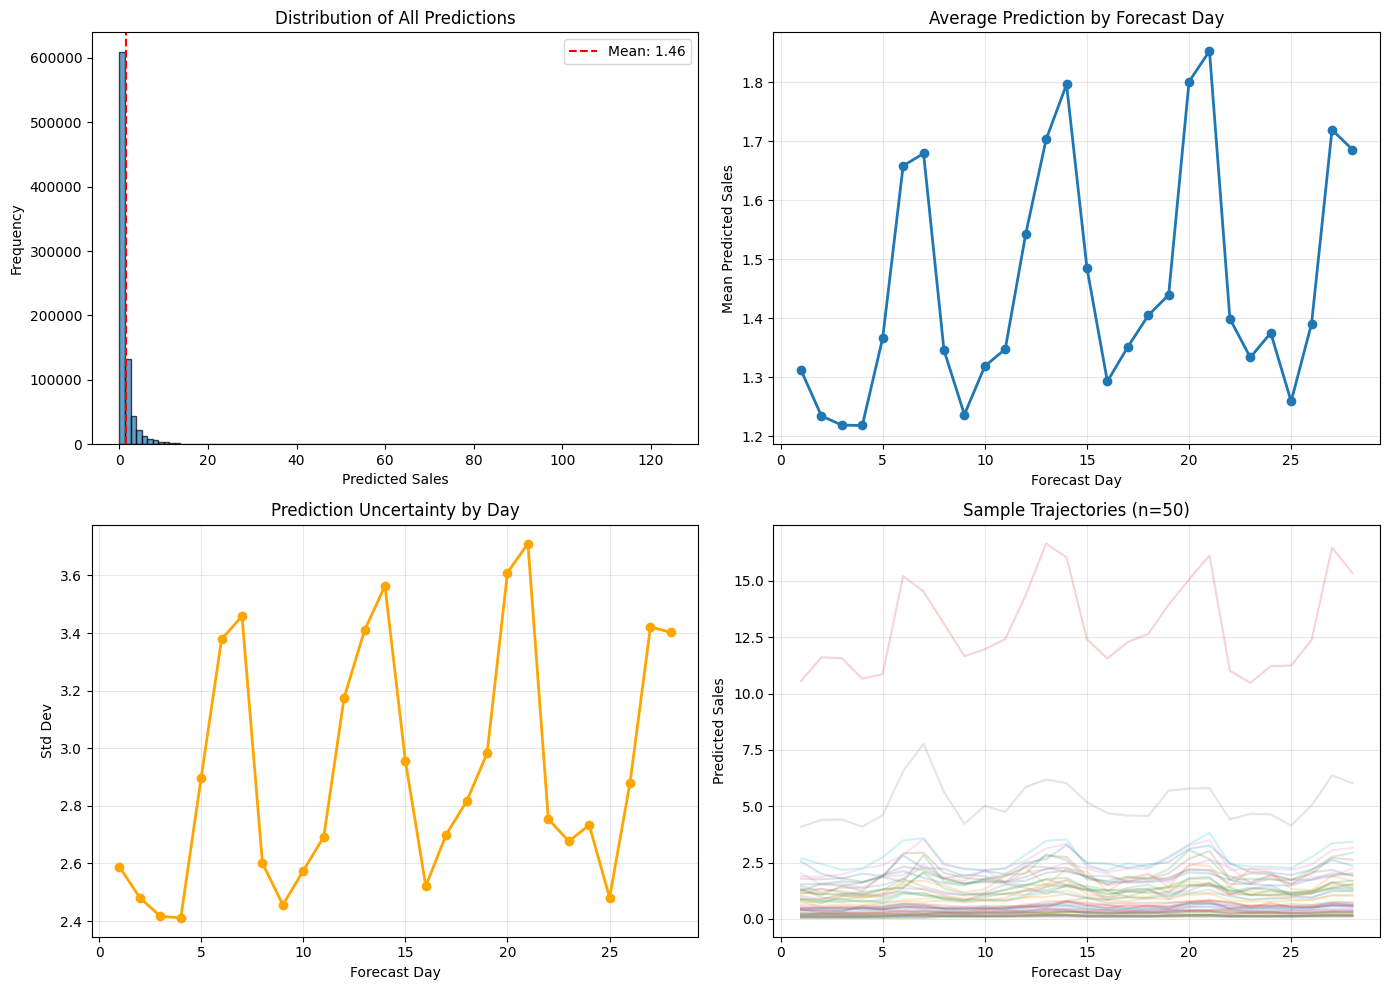

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Get validation predictions (first half)
n_ids = len(validation_sub)
val_preds = final_submission.iloc[:n_ids, 1:]

# Plot 1: Distribution
all_vals = val_preds.values.flatten()
axes[0, 0].hist(all_vals, bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Predicted Sales')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of All Predictions')
axes[0, 0].axvline(np.mean(all_vals), color='red', linestyle='--',
                    label=f'Mean: {np.mean(all_vals):.2f}')
axes[0, 0].legend()

# Plot 2: Mean by forecast day
mean_by_day = val_preds.mean()
axes[0, 1].plot(range(1, 29), mean_by_day.values, marker='o', linewidth=2)
axes[0, 1].set_xlabel('Forecast Day')
axes[0, 1].set_ylabel('Mean Predicted Sales')
axes[0, 1].set_title('Average Prediction by Forecast Day')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Std by day
std_by_day = val_preds.std()
axes[1, 0].plot(range(1, 29), std_by_day.values, marker='o', color='orange', linewidth=2)
axes[1, 0].set_xlabel('Forecast Day')
axes[1, 0].set_ylabel('Std Dev')
axes[1, 0].set_title('Prediction Uncertainty by Day')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Sample trajectories
n_samples = min(50, n_ids)
sample_idx = np.random.choice(n_ids, size=n_samples, replace=False)
for idx in sample_idx:
    axes[1, 1].plot(range(1, 29), val_preds.iloc[idx].values, alpha=0.2)
axes[1, 1].set_xlabel('Forecast Day')
axes[1, 1].set_ylabel('Predicted Sales')
axes[1, 1].set_title(f'Sample Trajectories (n={n_samples})')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 15. Summary Statistics

In [ ]:
print("="*80)
print("FORECAST SUMMARY")
print("="*80)

print(f"\nModel: {source}")
print(f"Iterations: {best_iteration}")
if validation_rmse:
    print(f"Validation RMSE (from Step 1): {validation_rmse:.6f}")

print(f"\nForecast period: Days {max_train_day + 1}–{max_train_day + 28}")
print(f"Number of IDs: {n_ids:,}")
print(f"Total predictions: {n_ids * 28:,}")

print("\nPrediction statistics:")
print(f"  Min:    {val_preds.min().min():.4f}")
print(f"  Max:    {val_preds.max().max():.4f}")
print(f"  Mean:   {val_preds.mean().mean():.4f}")
print(f"  Median: {val_preds.median().median():.4f}")
print(f"  Std:    {val_preds.std().mean():.4f}")

zero_count = (val_preds == 0).sum().sum()
print(f"\nZero predictions: {zero_count:,} ({zero_count / (n_ids * 28) * 100:.2f}%)")

print("\n" + "="*80)
print("✅ SUBMISSION READY FOR KAGGLE")
print("="*80)
print(f"\nUpload {SUBMISSION_PATH} to:")
print("https://www.kaggle.com/competitions/m5-forecasting-accuracy/submit")

FORECAST SUMMARY

Model: optuna_trial_37
Iterations: 152
Validation RMSE (from Step 1): 2.002561

Forecast period: Days 1942–1969
Number of IDs: 30,490
Total predictions: 853,720

Prediction statistics:
  Min:    0.0183
  Max:    124.5088
  Mean:   1.4560
  Median: 0.6481
  Std:    2.9197

Zero predictions: 0 (0.00%)

✅ SUBMISSION READY FOR KAGGLE

Upload /content/drive/MyDrive/Group Project - Predictive/Notebooks/Lgbm _ FT/m5_submission2.csv to:
https://www.kaggle.com/competitions/m5-forecasting-accuracy/submit


In [ ]:
submission.iloc[:, 1:].describe()

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
count,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000
mean,1.311719,1.233983,1.218456,1.217829,1.366629,1.658427,1.679589,1.345512,1.236392,1.318453,1.347488,1.542448,1.703281,1.796645,1.485212,1.292680,1.351066,1.404536,1.439413,1.801391,1.853251,1.398993,1.333305,1.374926,1.258633,1.390904,1.719649,1.686170
std,2.588116,2.480945,2.416948,2.410792,2.897963,3.378074,3.458691,2.601669,2.456275,2.574754,2.692093,3.175274,3.409200,3.563766,2.955802,2.521755,2.700506,2.815916,2.982481,3.609822,3.710510,2.754380,2.677139,2.733576,2.481469,2.880475,3.421047,3.402344
min,0.018505,0.018328,0.018328,0.018328,0.019182,0.020021,0.020092,0.065609,0.061465,0.061158,0.063423,0.064414,0.069980,0.070628,0.065192,0.062305,0.062221,0.063003,0.064414,0.068300,0.069246,0.064387,0.061886,0.063553,0.061169,0.062875,0.068300,0.069916
25%,0.269298,0.262483,0.262936,0.263123,0.287548,0.338971,0.342254,0.307463,0.296555,0.307571,0.302715,0.339232,0.376711,0.393702,0.326528,0.307094,0.308379,0.319447,0.329376,0.402008,0.408142,0.326391,0.311335,0.319785,0.304926,0.331003,0.390125,0.382306
50%,0.611142,0.581249,0.579060,0.577307,0.621952,0.767421,0.773995,0.645900,0.589776,0.627740,0.625274,0.700322,0.796214,0.833392,0.681732,0.616943,0.626192,0.650214,0.662367,0.834545,0.851367,0.656693,0.620202,0.636456,0.601208,0.651525,0.804352,0.785314
75%,1.331150,1.229423,1.224752,1.215653,1.351139,1.655360,1.692818,1.356918,1.214497,1.310649,1.316994,1.497399,1.700181,1.793547,1.472988,1.279136,1.315765,1.365589,1.396721,1.774364,1.825589,1.395811,1.289787,1.333711,1.230881,1.350231,1.697478,1.653674
max,78.114942,82.955509,77.797446,83.643351,115.288906,124.508790,111.166493,85.257127,80.992004,84.330447,86.525168,113.868475,119.971601,118.024236,91.619422,86.203571,86.613969,88.671523,114.699766,118.888984,118.255716,88.084526,86.346265,83.038712,83.181753,113.775365,120.791832,120.826707


In [ ]:
print("Prediction min:", submission.iloc[:, 1:].min().min())
print("Prediction max:", submission.iloc[:, 1:].max().max())
print("Prediction mean:", submission.iloc[:, 1:].values.mean())
print("Prediction median:", np.median(submission.iloc[:, 1:].values))

print("Historical demand mean:", df["demand"].mean())
print("Historical demand median:", df["demand"].median())
print("Historical demand max:", df["demand"].max())

Prediction min: 0.018327572272245494
Prediction max: 124.50879039454223
Prediction mean: 1.4559635372529083
Prediction median: 0.6726357899896288
Historical demand mean: 1.2684598527087867
Historical demand median: 0.0
Historical demand max: 349
